# Chapter 94 - Final Project: Compare All Models Built in the Course

The course progressed from probability tables to fixed-window neural networks and causal self-attention.

This final benchmark places the major model families side by side without pretending that one number captures every tradeoff.

## Learning goals

By the end of this chapter, you will be able to:

- compare uniform, unigram, bigram, n-gram, neural bigram, MLP, and GPT models;
- describe each model's context, fitted state, tokenizer, and compute cost;
- evaluate character models on identical held-out target positions;
- generate actual samples from every fitted model;
- interpret native subword loss separately from per-character loss; and
- explain the limits of a compact comparison table and bar chart.

## Define a fair but limited benchmark

Every character model will use the same lowercase tokenizer, training text, held-out text, and validation target positions.

The token-level GPT will use the same raw split but a BPE-style tokenizer learned only from training text.

All neural runs are deliberately small CPU experiments, so their ranking is evidence about this configuration rather than a universal model hierarchy.

No wall-clock timings are stored because machine load and hardware would make committed outputs unstable.

## Clarify “learned parameters”

Count models are fitted from data and store counts or probabilities, but they do not contain tensors optimized by gradient descent.

The table therefore distinguishes count-based fitted state from gradient-trained neural parameters.

Context means the previous tokens that can affect one next-token prediction.

## Build a paragraph-level raw-text split

The fixture uses the same small English corpus as the recent final projects.

Complete paragraphs are held out before training paragraphs are repeated, preventing exact validation passages from leaking into training repetitions.

In [1]:
paragraphs_raw = [
    """Alice was beginning to get very tired of sitting by her sister on the bank,
    and of having nothing to do. Once or twice she had peeped into the book her
    sister was reading, but it had no pictures or conversations in it, and what is
    the use of a book, thought Alice, without pictures or conversation?""",
    """So she was considering in her own mind, as well as she could, for the hot day
    made her feel very sleepy and stupid, whether the pleasure of making a daisy
    chain would be worth the trouble of getting up and picking the daisies, when
    suddenly a white rabbit with pink eyes ran close by her.""",
    """There was nothing so very remarkable in that; nor did Alice think it so very
    much out of the way to hear the rabbit say to itself, Oh dear! Oh dear! I shall
    be too late! But when the rabbit actually took a watch out of its waistcoat
    pocket, and looked at it, and then hurried on, Alice started to her feet.""",
    """The rabbit-hole went straight on like a tunnel for some way, and then dipped
    suddenly down, so suddenly that Alice had not a moment to think about stopping
    herself before she found herself falling down what seemed to be a very deep
    well.""",
    """Either the well was very deep, or she fell very slowly, for she had plenty of
    time as she went down to look about her and to wonder what was going to happen
    next. First, she tried to look down and make out what she was coming to, but it
    was too dark to see anything.""",
    """Down, down, down. Would the fall never come to an end? I wonder how many miles
    I have fallen by this time, she said aloud. I must be getting somewhere near
    the centre of the earth. Let me see: that would be four thousand miles down,
    I think.""",
]


def normalize_paragraph(paragraph: str) -> str:
    return " ".join(paragraph.split()).lower()


paragraphs = [normalize_paragraph(paragraph) for paragraph in paragraphs_raw]

In [2]:
import random  # noqa: I001


paragraph_indexes = list(range(len(paragraphs)))
split_random = random.Random(94)
split_random.shuffle(paragraph_indexes)
validation_indexes = set(paragraph_indexes[:2])
training_paragraphs = [
    paragraph
    for index, paragraph in enumerate(paragraphs)
    if index not in validation_indexes
]
validation_paragraphs = [
    paragraph
    for index, paragraph in enumerate(paragraphs)
    if index in validation_indexes
]
training_source = "\n\n".join(training_paragraphs)
validation_text = "\n\n".join(validation_paragraphs)
training_text = (training_source + "\n\n") * 12

print("training paragraphs:", len(training_paragraphs))
print("held-out paragraphs:", len(validation_paragraphs))
print("training characters after repetition:", len(training_text))
print("held-out characters:", len(validation_text))
print("held-out openings:")
for paragraph in validation_paragraphs:
    print("-", paragraph[:76] + "...")

training paragraphs: 4
held-out paragraphs: 2
training characters after repetition: 13212
held-out characters: 545
held-out openings:
- there was nothing so very remarkable in that; nor did alice think it so very...
- the rabbit-hole went straight on like a tunnel for some way, and then dipped...


The holdout has only two paragraphs, so all validation values remain noisy.

The benchmark is useful for tracing model capabilities, not for publishing a leaderboard.

## Create the shared character task

The fixed alphabet avoids learning validation sequence statistics while guaranteeing coverage.

All character losses use natural logarithms and are measured in nats per character.

In [3]:
import math  # noqa: I001

import torch


characters = sorted(set("\n abcdefghijklmnopqrstuvwxyz,.!?;:'-"))
character_to_id = {character: token_id for token_id, character in enumerate(characters)}
id_to_character = {
    token_id: character for character, token_id in character_to_id.items()
}


def encode_characters(text: str) -> list[int]:
    unknown_characters = sorted(set(text) - set(character_to_id))
    if unknown_characters:
        raise ValueError(f"Unknown characters: {unknown_characters}")
    return [character_to_id[character] for character in text]


def decode_characters(token_ids: list[int]) -> str:
    return "".join(id_to_character[token_id] for token_id in token_ids)


training_ids = torch.tensor(encode_characters(training_text), dtype=torch.long)
validation_ids = torch.tensor(encode_characters(validation_text), dtype=torch.long)
character_vocabulary_size = len(characters)
benchmark_start = 16
validation_targets = validation_ids[benchmark_start:]

assert decode_characters(training_ids.tolist()) == training_text
print("character vocabulary:", character_vocabulary_size)
print("shared validation targets:", validation_targets.numel())

character vocabulary: 36
shared validation targets: 529


## Evaluate identical character targets

Every character model predicts positions 16 through the end of the held-out stream.

Models with shorter contexts ignore the extra available prefix, while the character GPT can use all 16 preceding characters.

In [4]:
def average_negative_log_probability(probabilities: list[float]) -> float:
    if not probabilities or any(probability <= 0 for probability in probabilities):
        raise ValueError("Probabilities must be nonempty and positive.")
    return sum(-math.log(probability) for probability in probabilities) / len(
        probabilities
    )


def smoothed_distribution(counts: list[int], smoothing: float) -> list[float]:
    denominator = sum(counts) + smoothing * len(counts)
    return [(count + smoothing) / denominator for count in counts]

## Fit uniform and unigram baselines

Uniform random assigns every character probability `1 / V`, while unigram learns one smoothed frequency distribution and still ignores context.

In [5]:
uniform_probabilities = [1.0 / character_vocabulary_size] * character_vocabulary_size
unigram_counts = [0] * character_vocabulary_size
for token_id in training_ids.tolist():
    unigram_counts[token_id] += 1
unigram_probabilities = smoothed_distribution(unigram_counts, smoothing=0.1)

uniform_loss = math.log(character_vocabulary_size)
unigram_loss = average_negative_log_probability(
    [unigram_probabilities[int(token_id)] for token_id in validation_targets.tolist()]
)
print("uniform validation loss:", round(uniform_loss, 3))
print("unigram validation loss:", round(unigram_loss, 3))

uniform validation loss: 3.584
unigram validation loss: 2.957


The frequency model should improve on uniform random because spaces and letters are not equally common.

## Fit bigram and 4-gram count models

Bigram conditions on one preceding character.

The 4-gram uses three preceding characters and backs off to bigram probabilities when a held-out context was never counted.

In [6]:
from collections import Counter  # noqa: I001
from dataclasses import dataclass  # noqa: I001


bigram_counts = [
    [0] * character_vocabulary_size for _ in range(character_vocabulary_size)
]
training_id_list = training_ids.tolist()
for current_id, next_id in zip(training_id_list, training_id_list[1:], strict=False):
    bigram_counts[current_id][next_id] += 1
bigram_probabilities = [
    smoothed_distribution(row, smoothing=0.1) for row in bigram_counts
]


@dataclass(frozen=True)
class NGramModel:
    context_length: int
    counts_by_context: dict[tuple[int, ...], Counter[int]]


def train_ngram_model(token_ids: list[int], context_length: int) -> NGramModel:
    counts_by_context: dict[tuple[int, ...], Counter[int]] = {}
    for target_position in range(context_length, len(token_ids)):
        context = tuple(token_ids[target_position - context_length : target_position])
        counts_by_context.setdefault(context, Counter())[
            token_ids[target_position]
        ] += 1
    return NGramModel(context_length, counts_by_context)


ngram_model = train_ngram_model(training_id_list, context_length=3)


def ngram_probability(
    model: NGramModel, context: tuple[int, ...], target_id: int
) -> float:
    counts = model.counts_by_context.get(context)
    if counts is None:
        return bigram_probabilities[context[-1]][target_id]
    denominator = sum(counts.values()) + 0.1 * character_vocabulary_size
    return (counts[target_id] + 0.1) / denominator

In [7]:
validation_id_list = validation_ids.tolist()
bigram_loss = average_negative_log_probability(
    [
        bigram_probabilities[validation_id_list[position - 1]][
            validation_id_list[position]
        ]
        for position in range(benchmark_start, len(validation_id_list))
    ]
)
ngram_loss = average_negative_log_probability(
    [
        ngram_probability(
            ngram_model,
            tuple(validation_id_list[position - 3 : position]),
            validation_id_list[position],
        )
        for position in range(benchmark_start, len(validation_id_list))
    ]
)
seen_validation_contexts = sum(
    tuple(validation_id_list[position - 3 : position]) in ngram_model.counts_by_context
    for position in range(benchmark_start, len(validation_id_list))
)
print("bigram validation loss:", round(bigram_loss, 3))
print("4-gram validation loss:", round(ngram_loss, 3))
print(
    "4-gram context coverage:",
    f"{seen_validation_contexts / validation_targets.numel():.1%}",
)

bigram validation loss: 2.65
4-gram validation loss: 2.708
4-gram context coverage: 69.0%


The coverage output explains when the longer count model can use its full context and when it must fall back.

Longer count context is useful only when the corresponding table entry has evidence.

## Define neural bigram and fixed-window MLP models

The neural bigram learns a dense next-character score row for each current character.

The MLP embeds eight preceding characters, flattens their vectors, and applies a nonlinear hidden layer.

In [8]:
class NeuralBigram(torch.nn.Module):
    def __init__(self, vocabulary_size: int) -> None:
        super().__init__()
        self.score_table = torch.nn.Embedding(vocabulary_size, vocabulary_size)

    def forward(self, input_ids: torch.Tensor) -> torch.Tensor:
        logits: torch.Tensor = self.score_table(input_ids)
        return logits


class MLPCharacterModel(torch.nn.Module):
    context_length: int

    def __init__(self, vocabulary_size: int, context_length: int) -> None:
        super().__init__()
        self.context_length = context_length
        self.embedding = torch.nn.Embedding(vocabulary_size, 16)
        self.hidden = torch.nn.Linear(context_length * 16, 64)
        self.output = torch.nn.Linear(64, vocabulary_size)

    def forward(self, input_ids: torch.Tensor) -> torch.Tensor:
        if input_ids.ndim != 2 or input_ids.shape[1] != self.context_length:
            raise ValueError("MLP inputs must match its fixed context length.")
        embeddings = self.embedding(input_ids)
        flattened = embeddings.reshape(input_ids.shape[0], -1)
        logits: torch.Tensor = self.output(torch.tanh(self.hidden(flattened)))
        return logits

## Sample neural training windows

The helper selects target positions and returns exactly the preceding context required by a model.

In [9]:
def sample_context_batch(
    token_ids: torch.Tensor,
    context_length: int,
    batch_size: int,
    generator: torch.Generator,
) -> tuple[torch.Tensor, torch.Tensor]:
    target_positions = torch.randint(
        context_length,
        token_ids.shape[0],
        (batch_size,),
        generator=generator,
    )
    contexts = torch.stack(
        [
            token_ids[position - context_length : position]
            for position in target_positions
        ]
    )
    targets = token_ids[target_positions]
    return contexts, targets


def all_validation_contexts(
    token_ids: torch.Tensor, context_length: int
) -> torch.Tensor:
    return torch.stack(
        [
            token_ids[position - context_length : position]
            for position in range(benchmark_start, token_ids.shape[0])
        ]
    )

## Train neural bigram and MLP

Both runs use AdamW and fixed update budgets rather than wall-clock stopping.

In [10]:
torch.manual_seed(9401)
neural_bigram_model = NeuralBigram(character_vocabulary_size)
neural_bigram_optimizer = torch.optim.AdamW(neural_bigram_model.parameters(), lr=0.03)
neural_bigram_generator = torch.Generator().manual_seed(9402)
for _ in range(250):
    contexts, targets = sample_context_batch(
        training_ids, 1, 128, neural_bigram_generator
    )
    logits = neural_bigram_model(contexts[:, -1])
    loss = torch.nn.functional.cross_entropy(logits, targets)
    neural_bigram_optimizer.zero_grad(set_to_none=True)
    loss.backward()  # type: ignore[no-untyped-call]
    neural_bigram_optimizer.step()

torch.manual_seed(9403)
mlp_model = MLPCharacterModel(character_vocabulary_size, context_length=8)
mlp_optimizer = torch.optim.AdamW(mlp_model.parameters(), lr=0.003)
mlp_generator = torch.Generator().manual_seed(9404)
for _ in range(100):
    contexts, targets = sample_context_batch(training_ids, 8, 128, mlp_generator)
    logits = mlp_model(contexts)
    loss = torch.nn.functional.cross_entropy(logits, targets)
    mlp_optimizer.zero_grad(set_to_none=True)
    loss.backward()  # type: ignore[no-untyped-call]
    mlp_optimizer.step()

with torch.no_grad():
    neural_bigram_logits = neural_bigram_model(validation_ids[benchmark_start - 1 : -1])
    neural_bigram_loss = torch.nn.functional.cross_entropy(
        neural_bigram_logits, validation_targets
    ).item()
    mlp_logits = mlp_model(all_validation_contexts(validation_ids, 8))
    mlp_loss = torch.nn.functional.cross_entropy(mlp_logits, validation_targets).item()

print("neural bigram validation loss:", round(neural_bigram_loss, 3))
print("MLP validation loss:", round(mlp_loss, 3))

neural bigram validation loss: 2.582
MLP validation loss: 2.703


The neural bigram has the same one-character information limit as the count bigram even though its probabilities are learned by gradient descent.

The MLP can use an eight-character fixed window but cannot dynamically route information between positions.

## Define the shared GPT architecture

The character and subword GPTs use the same causal-attention implementation, with vocabulary size supplied at construction time.

In [11]:
import math  # noqa: I001
import torch


class MultiHeadCausalSelfAttention(torch.nn.Module):
    embedding_dimension: int
    number_of_attention_heads: int
    head_size: int

    def __init__(
        self,
        embedding_dimension: int,
        number_of_attention_heads: int,
        context_length: int,
        dropout_rate: float,
    ) -> None:
        super().__init__()
        if embedding_dimension % number_of_attention_heads != 0:
            raise ValueError("Attention heads must divide the embedding dimension.")
        self.embedding_dimension = embedding_dimension
        self.number_of_attention_heads = number_of_attention_heads
        self.head_size = embedding_dimension // number_of_attention_heads
        self.query_projection = torch.nn.Linear(
            embedding_dimension, embedding_dimension, bias=False
        )
        self.key_projection = torch.nn.Linear(
            embedding_dimension, embedding_dimension, bias=False
        )
        self.value_projection = torch.nn.Linear(
            embedding_dimension, embedding_dimension, bias=False
        )
        self.output_projection = torch.nn.Linear(
            embedding_dimension, embedding_dimension
        )
        self.attention_dropout = torch.nn.Dropout(dropout_rate)
        self.output_dropout = torch.nn.Dropout(dropout_rate)
        self.register_buffer(
            "causal_mask",
            torch.tril(torch.ones(context_length, context_length, dtype=torch.bool)),
        )

    def forward(self, input_values: torch.Tensor) -> torch.Tensor:
        batch_size, sequence_length, _ = input_values.shape

        def split_heads(values: torch.Tensor) -> torch.Tensor:
            return values.view(
                batch_size,
                sequence_length,
                self.number_of_attention_heads,
                self.head_size,
            ).transpose(1, 2)

        queries = split_heads(self.query_projection(input_values))
        keys = split_heads(self.key_projection(input_values))
        values = split_heads(self.value_projection(input_values))
        attention_scores = queries @ keys.transpose(-2, -1)
        attention_scores = attention_scores / math.sqrt(self.head_size)
        causal_mask = self.causal_mask[:sequence_length, :sequence_length]
        attention_scores = attention_scores.masked_fill(~causal_mask, float("-inf"))
        attention_weights = torch.softmax(attention_scores, dim=-1)
        attended_values = self.attention_dropout(attention_weights) @ values
        concatenated_values = (
            attended_values.transpose(1, 2)
            .contiguous()
            .view(batch_size, sequence_length, self.embedding_dimension)
        )
        projected_values = self.output_projection(concatenated_values)
        output_values: torch.Tensor = self.output_dropout(projected_values)
        return output_values

In [12]:
class FeedForwardNetwork(torch.nn.Module):
    def __init__(self, embedding_dimension: int, dropout_rate: float) -> None:
        super().__init__()
        self.network = torch.nn.Sequential(
            torch.nn.Linear(embedding_dimension, 4 * embedding_dimension),
            torch.nn.ReLU(),
            torch.nn.Linear(4 * embedding_dimension, embedding_dimension),
            torch.nn.Dropout(dropout_rate),
        )

    def forward(self, input_values: torch.Tensor) -> torch.Tensor:
        output_values: torch.Tensor = self.network(input_values)
        return output_values


class TransformerBlock(torch.nn.Module):
    def __init__(
        self,
        embedding_dimension: int,
        number_of_attention_heads: int,
        context_length: int,
        dropout_rate: float,
    ) -> None:
        super().__init__()
        self.attention_norm = torch.nn.LayerNorm(embedding_dimension)
        self.attention = MultiHeadCausalSelfAttention(
            embedding_dimension=embedding_dimension,
            number_of_attention_heads=number_of_attention_heads,
            context_length=context_length,
            dropout_rate=dropout_rate,
        )
        self.feedforward_norm = torch.nn.LayerNorm(embedding_dimension)
        self.feedforward = FeedForwardNetwork(
            embedding_dimension=embedding_dimension,
            dropout_rate=dropout_rate,
        )

    def forward(self, input_values: torch.Tensor) -> torch.Tensor:
        attention_branch = self.attention(self.attention_norm(input_values))
        values_after_attention = input_values + attention_branch
        feedforward_branch = self.feedforward(
            self.feedforward_norm(values_after_attention)
        )
        output_values: torch.Tensor = values_after_attention + feedforward_branch
        return output_values


class TinyGPT(torch.nn.Module):
    vocabulary_size: int
    context_length: int

    def __init__(
        self,
        vocabulary_size: int,
        context_length: int,
        embedding_dimension: int,
        number_of_attention_heads: int,
        number_of_transformer_blocks: int,
        dropout_rate: float,
    ) -> None:
        super().__init__()
        self.vocabulary_size = vocabulary_size
        self.context_length = context_length
        self.token_embedding = torch.nn.Embedding(vocabulary_size, embedding_dimension)
        self.position_embedding = torch.nn.Embedding(
            context_length, embedding_dimension
        )
        self.embedding_dropout = torch.nn.Dropout(dropout_rate)
        self.transformer_blocks = torch.nn.Sequential(
            *[
                TransformerBlock(
                    embedding_dimension=embedding_dimension,
                    number_of_attention_heads=number_of_attention_heads,
                    context_length=context_length,
                    dropout_rate=dropout_rate,
                )
                for _ in range(number_of_transformer_blocks)
            ]
        )
        self.final_norm = torch.nn.LayerNorm(embedding_dimension)
        self.output_layer = torch.nn.Linear(embedding_dimension, vocabulary_size)

    def forward(
        self,
        input_token_ids: torch.Tensor,
        target_token_ids: torch.Tensor | None = None,
    ) -> tuple[torch.Tensor, torch.Tensor | None]:
        if input_token_ids.ndim != 2:
            raise ValueError("Inputs must have shape [batch, time].")
        batch_size, sequence_length = input_token_ids.shape
        if sequence_length > self.context_length:
            raise ValueError("Input exceeds model context length.")
        position_ids = torch.arange(sequence_length, device=input_token_ids.device)
        hidden_values = self.token_embedding(input_token_ids)
        hidden_values = hidden_values + self.position_embedding(position_ids)
        hidden_values = self.embedding_dropout(hidden_values)
        hidden_values = self.transformer_blocks(hidden_values)
        logits = self.output_layer(self.final_norm(hidden_values))
        loss = None
        if target_token_ids is not None:
            if target_token_ids.shape != input_token_ids.shape:
                raise ValueError("Targets must have the same shape as inputs.")
            loss = torch.nn.functional.cross_entropy(
                logits.reshape(batch_size * sequence_length, self.vocabulary_size),
                target_token_ids.reshape(batch_size * sequence_length),
            )
        return logits, loss

    @torch.no_grad()
    def generate(
        self,
        input_token_ids: torch.Tensor,
        number_of_new_tokens: int,
        generator: torch.Generator,
        temperature: float = 1.0,
        top_k: int | None = None,
    ) -> torch.Tensor:
        if temperature <= 0:
            raise ValueError("temperature must be positive.")
        generated_ids = input_token_ids
        for _ in range(number_of_new_tokens):
            model_input = generated_ids[:, -self.context_length :]
            logits, _ = self(model_input)
            next_logits = logits[:, -1] / temperature
            if top_k is not None:
                effective_top_k = min(top_k, self.vocabulary_size)
                top_values, _ = torch.topk(next_logits, effective_top_k)
                next_logits = next_logits.masked_fill(
                    next_logits < top_values[:, -1, None], float("-inf")
                )
            probabilities = torch.softmax(next_logits, dim=-1)
            next_ids = torch.multinomial(
                probabilities, num_samples=1, generator=generator
            )
            generated_ids = torch.cat([generated_ids, next_ids], dim=1)
        return generated_ids

## Train the character GPT

The model receives 16-character sequences and computes a loss at every shifted position during each update.

In [13]:
def sample_shifted_batch(
    token_ids: torch.Tensor,
    context_length: int,
    batch_size: int,
    generator: torch.Generator,
) -> tuple[torch.Tensor, torch.Tensor]:
    number_of_starts = token_ids.shape[0] - context_length
    starts = torch.randint(0, number_of_starts, (batch_size,), generator=generator)
    inputs = torch.stack(
        [token_ids[start : start + context_length] for start in starts]
    )
    targets = torch.stack(
        [token_ids[start + 1 : start + context_length + 1] for start in starts]
    )
    return inputs, targets


torch.manual_seed(9405)
character_gpt = TinyGPT(
    vocabulary_size=character_vocabulary_size,
    context_length=16,
    embedding_dimension=48,
    number_of_attention_heads=4,
    number_of_transformer_blocks=2,
    dropout_rate=0.1,
)
character_gpt_optimizer = torch.optim.AdamW(
    character_gpt.parameters(), lr=5e-4, weight_decay=0.01
)
character_gpt_generator = torch.Generator().manual_seed(9406)
character_gpt.train()
for _ in range(400):
    inputs, targets = sample_shifted_batch(
        training_ids, 16, 32, character_gpt_generator
    )
    _, loss = character_gpt(inputs, targets)
    if loss is None or not torch.isfinite(loss):
        raise RuntimeError("Character GPT produced an invalid loss.")
    character_gpt_optimizer.zero_grad(set_to_none=True)
    loss.backward()  # type: ignore[no-untyped-call]
    torch.nn.utils.clip_grad_norm_(character_gpt.parameters(), 1.0)
    character_gpt_optimizer.step()

character_gpt.eval()
with torch.no_grad():
    character_gpt_contexts = all_validation_contexts(validation_ids, 16)
    character_gpt_logits, _ = character_gpt(character_gpt_contexts)
    character_gpt_loss = torch.nn.functional.cross_entropy(
        character_gpt_logits[:, -1], validation_targets
    ).item()
print("character GPT validation loss:", round(character_gpt_loss, 3))

character GPT validation loss: 2.495


The exact validation pass uses the final logit from one 16-character window for every shared target position.

## Train a small BPE-style tokenizer

The tokenizer begins with the same fixed character alphabet and learns 40 ordered pair merges only from training text.

Subword tokens concatenate back to the original text exactly.

In [14]:
TokenPair = tuple[str, str]


@dataclass(frozen=True)
class MergeRule:
    pair: TokenPair
    new_token: str


def merge_pair(tokens: list[str], pair: TokenPair, merged: str) -> list[str]:
    output: list[str] = []
    position = 0
    while position < len(tokens):
        if (
            position + 1 < len(tokens)
            and tokens[position] == pair[0]
            and tokens[position + 1] == pair[1]
        ):
            output.append(merged)
            position += 2
        else:
            output.append(tokens[position])
            position += 1
    return output


class BPETokenizer:
    def __init__(self, number_of_merges: int) -> None:
        self.number_of_merges = number_of_merges
        self.merge_rules: list[MergeRule] = []
        self.token_to_id: dict[str, int] = {}
        self.id_to_token: dict[int, str] = {}

    def train(self, text: str) -> None:
        tokens = list(text)
        vocabulary = set(characters)
        rules: list[MergeRule] = []
        for _ in range(self.number_of_merges):
            pair_counts = Counter(zip(tokens, tokens[1:], strict=False))
            candidates = sorted(
                pair_counts,
                key=lambda pair: (-pair_counts[pair], pair),
            )
            pair = next(
                (
                    candidate
                    for candidate in candidates
                    if "".join(candidate) not in vocabulary
                ),
                None,
            )
            if pair is None:
                break
            new_token = "".join(pair)
            tokens = merge_pair(tokens, pair, new_token)
            rules.append(MergeRule(pair, new_token))
            vocabulary.add(new_token)
        self.merge_rules = rules
        self.token_to_id = {
            token: token_id for token_id, token in enumerate(sorted(vocabulary))
        }
        self.id_to_token = {
            token_id: token for token, token_id in self.token_to_id.items()
        }

    def encode_tokens(self, text: str) -> list[str]:
        tokens = list(text)
        for rule in self.merge_rules:
            tokens = merge_pair(tokens, rule.pair, rule.new_token)
        return tokens

    def encode(self, text: str) -> list[int]:
        return [self.token_to_id[token] for token in self.encode_tokens(text)]

    def decode(self, token_ids: list[int]) -> str:
        return "".join(self.id_to_token[token_id] for token_id in token_ids)


bpe_tokenizer = BPETokenizer(number_of_merges=40)
bpe_tokenizer.train(training_source)
bpe_training_ids = torch.tensor(bpe_tokenizer.encode(training_text), dtype=torch.long)
bpe_validation_ids = torch.tensor(
    bpe_tokenizer.encode(validation_text), dtype=torch.long
)
assert bpe_tokenizer.decode(bpe_training_ids.tolist()) == training_text
assert bpe_tokenizer.decode(bpe_validation_ids.tolist()) == validation_text
print("BPE vocabulary size:", len(bpe_tokenizer.token_to_id))
print("validation characters:", len(validation_text))
print("validation subword tokens:", bpe_validation_ids.numel())

BPE vocabulary size: 76
validation characters: 545
validation subword tokens: 379


## Train the token-level GPT

The token GPT uses the same hidden dimensions and update count as the character GPT, but each context position may represent multiple characters.

In [15]:
token_context_length = 16
torch.manual_seed(9407)
token_gpt = TinyGPT(
    vocabulary_size=len(bpe_tokenizer.token_to_id),
    context_length=token_context_length,
    embedding_dimension=48,
    number_of_attention_heads=4,
    number_of_transformer_blocks=2,
    dropout_rate=0.1,
)
token_gpt_optimizer = torch.optim.AdamW(
    token_gpt.parameters(), lr=5e-4, weight_decay=0.01
)
token_gpt_generator = torch.Generator().manual_seed(9408)
token_gpt.train()
for _ in range(400):
    inputs, targets = sample_shifted_batch(
        bpe_training_ids, token_context_length, 32, token_gpt_generator
    )
    _, loss = token_gpt(inputs, targets)
    if loss is None or not torch.isfinite(loss):
        raise RuntimeError("Token GPT produced an invalid loss.")
    token_gpt_optimizer.zero_grad(set_to_none=True)
    loss.backward()  # type: ignore[no-untyped-call]
    torch.nn.utils.clip_grad_norm_(token_gpt.parameters(), 1.0)
    token_gpt_optimizer.step()

token_gpt.eval()
token_target_positions = range(token_context_length, bpe_validation_ids.shape[0])
token_contexts = torch.stack(
    [
        bpe_validation_ids[position - token_context_length : position]
        for position in token_target_positions
    ]
)
token_targets = bpe_validation_ids[token_context_length:]
with torch.no_grad():
    token_logits, _ = token_gpt(token_contexts)
    token_gpt_loss = torch.nn.functional.cross_entropy(
        token_logits[:, -1], token_targets
    ).item()
print("token GPT native validation loss:", round(token_gpt_loss, 3))
print("loss unit: nats per BPE token")

token GPT native validation loss: 3.751
loss unit: nats per BPE token


Native token loss is not placed on the character-loss chart because a BPE token can contain several characters.

Equal numeric values would therefore describe different prediction units and different amounts of raw text.

## Generate real samples from every model

All character models begin with `alice was` and generate 160 characters with explicit random seeds.

The token GPT generates 70 subword tokens, so its raw character length is allowed to differ.

In [16]:
prompt = "alice was"


def sample_from_weights(
    values: list[int], weights: list[float], generator: random.Random
) -> int:
    return generator.choices(values, weights=weights, k=1)[0]


def generate_count_sample(model_name: str, seed: int, length: int = 160) -> str:
    generator = random.Random(seed)
    generated = encode_characters(prompt)
    token_values = list(range(character_vocabulary_size))
    for _ in range(length):
        if model_name == "uniform random":
            probabilities = uniform_probabilities
        elif model_name == "unigram":
            probabilities = unigram_probabilities
        elif model_name == "bigram":
            probabilities = bigram_probabilities[generated[-1]]
        elif model_name == "4-gram":
            context = tuple(generated[-3:])
            probabilities = [
                ngram_probability(ngram_model, context, target_id)
                for target_id in token_values
            ]
        else:
            raise ValueError("Unknown count model.")
        generated.append(sample_from_weights(token_values, probabilities, generator))
    return decode_characters(generated)


@torch.no_grad()
def generate_neural_character_sample(
    model_name: str, seed: int, length: int = 160
) -> str:
    generator = torch.Generator().manual_seed(seed)
    generated = torch.tensor([encode_characters(prompt)], dtype=torch.long)
    for _ in range(length):
        if model_name == "neural bigram":
            logits = neural_bigram_model(generated[:, -1])
        elif model_name == "MLP":
            logits = mlp_model(generated[:, -8:])
        elif model_name == "character GPT":
            gpt_logits, _ = character_gpt(generated[:, -16:])
            logits = gpt_logits[:, -1]
        else:
            raise ValueError("Unknown neural character model.")
        probabilities = torch.softmax(logits / 0.8, dim=-1)
        next_id = torch.multinomial(probabilities, 1, generator=generator)
        generated = torch.cat([generated, next_id], dim=1)
    return decode_characters(generated[0].tolist())

In [17]:
character_samples = {
    "uniform random": generate_count_sample("uniform random", 9410),
    "unigram": generate_count_sample("unigram", 9411),
    "bigram": generate_count_sample("bigram", 9412),
    "4-gram": generate_count_sample("4-gram", 9413),
    "neural bigram": generate_neural_character_sample("neural bigram", 9414),
    "MLP": generate_neural_character_sample("MLP", 9415),
    "character GPT": generate_neural_character_sample("character GPT", 9416),
}

token_prompt_ids = torch.tensor([bpe_tokenizer.encode(prompt)], dtype=torch.long)
token_sample_generator = torch.Generator().manual_seed(9417)
with torch.no_grad():
    token_generated_ids = token_gpt.generate(
        token_prompt_ids,
        number_of_new_tokens=70,
        generator=token_sample_generator,
        temperature=0.8,
        top_k=15,
    )
token_sample = bpe_tokenizer.decode(token_generated_ids[0].tolist())

for model_name, sample in [*character_samples.items(), ("token GPT", token_sample)]:
    print("=" * 72)
    print(model_name)
    print(sample)

uniform random
alice was,xtdzidm!oozynphvrqjfh.:kgbaq;umea,?pnwksxn x lw
kt'
-oo'
y.!xwek:?pej!tubzexpyce:lz
mwpvhrwjj.mzc!:-.j
-egepqkyzx.pynlwsxoeyk,bjx'';'!ws jl.-cniptn?tqch?sxivat
unigram
alice was noy ad  st eufit aelctftdhntsdtrhmvird   y o n ovvo sf  tthla ehnfeow lathldd  tdnasho inshro   hgsise tseggeoukfet  ofby
d gora  ,totb rr    ,wvvoeiday  ep a 
bigram
alice was ice werindouthas nd, o o. allin f in?



ar fis wng ba io sale veen cot es, e py maverasthar is sidal veler ho when, doud, t omy stowng medd o ti waity ary tic
4-gram
alice was convery ther this-ceatwak wnnge was comr was well nles dwher and what whetwher.
ll as withe could bqilowly,sitting nothing b, me see as she would? let me'kicok
neural bigram
alice wasising oumiling wo on ss mad tsandoure s he t wof arete r s tothort d mankl as bery d ing vfad o siconshe sing shofoupl core tr avee t s she wo, pimes by tisave 
MLP
alice was dore nocthe fincd hou dasuen an don an, oi wus sorey ur houe tog wnd mopl
 ou y ttiws

Samples reveal capability differences that average loss cannot show, but one sample per model is still anecdotal.

Uniform and unigram lack order, transition models improve local texture, fixed-window models can form longer fragments, and GPTs can condition on every position in their windows.

## Build the measured summary table

The generation column describes the mechanism visible in this run rather than claiming a universal quality ranking.

Parameter counts include gradient-trained tensors only, while count rows report zero neural parameters.

In [18]:
@dataclass(frozen=True)
class ComparisonRow:
    model: str
    context: str
    learned_parameters: str
    tokenizer: str
    validation_loss: float
    loss_unit: str
    generation_behavior: str
    cpu_cost: str
    neural_parameters: int
    note: str


comparison_rows = [
    ComparisonRow(
        "uniform random",
        "none",
        "none",
        "character",
        uniform_loss,
        "nat/char",
        "random symbols",
        "very low",
        0,
        "No fitted state.",
    ),
    ComparisonRow(
        "unigram",
        "none",
        "counts",
        "character",
        unigram_loss,
        "nat/char",
        "frequent chars",
        "very low",
        0,
        "Ignores order.",
    ),
    ComparisonRow(
        "bigram",
        "1 char",
        "counts",
        "character",
        bigram_loss,
        "nat/char",
        "local pairs",
        "very low",
        0,
        "One-step transitions.",
    ),
    ComparisonRow(
        "4-gram",
        "3 chars",
        "counts",
        "character",
        ngram_loss,
        "nat/char",
        "familiar fragments",
        "low",
        0,
        "Backs off on unseen contexts.",
    ),
    ComparisonRow(
        "neural bigram",
        "1 char",
        "gradient tensors",
        "character",
        neural_bigram_loss,
        "nat/char",
        "learned pairs",
        "low",
        sum(parameter.numel() for parameter in neural_bigram_model.parameters()),
        "Same context limit as bigram.",
    ),
    ComparisonRow(
        "MLP",
        "8 chars",
        "gradient tensors",
        "character",
        mlp_loss,
        "nat/char",
        "fixed-window text",
        "medium",
        sum(parameter.numel() for parameter in mlp_model.parameters()),
        "Flattens a fixed window.",
    ),
    ComparisonRow(
        "character GPT",
        "16 chars",
        "gradient tensors",
        "character",
        character_gpt_loss,
        "nat/char",
        "attention fragments",
        "medium-high",
        sum(parameter.numel() for parameter in character_gpt.parameters()),
        "Causal attention over characters.",
    ),
    ComparisonRow(
        "token GPT",
        "16 subwords",
        "gradient tensors",
        "BPE-style",
        token_gpt_loss,
        "nat/subword",
        "subword fragments",
        "high",
        sum(parameter.numel() for parameter in token_gpt.parameters()),
        "Native loss is not comparable to nat/char.",
    ),
]


def print_comparison_table(rows: list[ComparisonRow]) -> None:
    print(
        f"{'model':<16} {'context':<12} {'learned parameters':<17} "
        f"{'tokenizer':<10} {'val loss':>8} {'unit':<12} "
        f"{'generation':<19} {'CPU':<11}"
    )
    print("-" * 120)
    for row in rows:
        print(
            f"{row.model:<16} {row.context:<12} {row.learned_parameters:<17} "
            f"{row.tokenizer:<10} {row.validation_loss:>8.3f} "
            f"{row.loss_unit:<12} {row.generation_behavior:<19} {row.cpu_cost:<11}"
        )


print_comparison_table(comparison_rows)

model            context      learned parameters tokenizer  val loss unit         generation          CPU        
------------------------------------------------------------------------------------------------------------------------
uniform random   none         none              character     3.584 nat/char     random symbols      very low   
unigram          none         counts            character     2.957 nat/char     frequent chars      very low   
bigram           1 char       counts            character     2.650 nat/char     local pairs         very low   
4-gram           3 chars      counts            character     2.708 nat/char     familiar fragments  low        
neural bigram    1 char       gradient tensors  character     2.582 nat/char     learned pairs       low        
MLP              8 chars      gradient tensors  character     2.703 nat/char     fixed-window text   medium     
character GPT    16 chars     gradient tensors  character     2.495 nat/char     attent

In [19]:
print("model".ljust(18), "neural parameters".rjust(18), "comparison note")
print("-" * 84)
for row in comparison_rows:
    print(row.model.ljust(18), str(row.neural_parameters).rjust(18), row.note)
print()
print("gradient update budgets:")
print("neural bigram=250 | MLP=100 | character GPT=400 | token GPT=400")

model               neural parameters comparison note
------------------------------------------------------------------------------------
uniform random                      0 No fitted state.
unigram                             0 Ignores order.
bigram                              0 One-step transitions.
4-gram                              0 Backs off on unseen contexts.
neural bigram                    1296 Same context limit as bigram.
MLP                             11172 Flattens a fixed window.
character GPT                   60612 Causal attention over characters.
token GPT                       64492 Native loss is not comparable to nat/char.

gradient update budgets:
neural bigram=250 | MLP=100 | character GPT=400 | token GPT=400


The table answers several questions at once, but its CPU bands summarize this notebook's update budgets and structural complexity rather than measured elapsed time.

Count-table memory can also grow sharply with vocabulary and n-gram order even though neural parameter count is zero.

## Plot only comparable validation losses

The required bar chart excludes the token-level GPT because its denominator is a BPE token rather than a character.

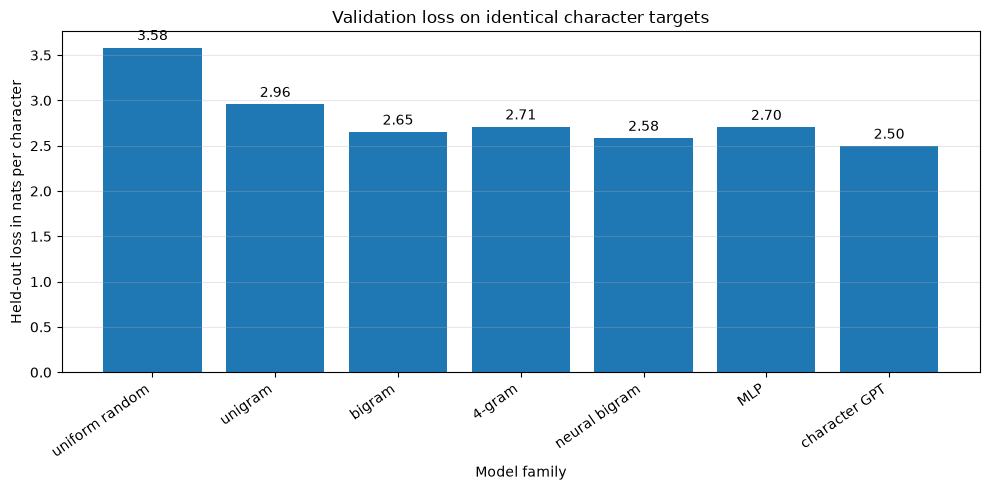

In [20]:
import matplotlib.pyplot as plt  # noqa: I001


character_rows = [row for row in comparison_rows if row.loss_unit == "nat/char"]
plt.figure(figsize=(10, 5))
bars = plt.bar(
    [row.model for row in character_rows],
    [row.validation_loss for row in character_rows],
)
plt.bar_label(bars, fmt="%.2f", padding=3)
plt.xlabel("Model family")
plt.ylabel("Held-out loss in nats per character")
plt.title("Validation loss on identical character targets")
plt.xticks(rotation=35, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

Lower bars mean better next-character probability assignments on this split.

They do not measure generation coherence, memorization, training cost, or performance on other corpora.

In this run, the character GPT has the lowest character loss and the neural bigram narrowly improves on the count bigram.

The 4-gram and MLP do not beat the bigram, illustrating that extra context does not guarantee improvement with sparse data, limited tuning, and small update budgets.

## Why token loss is separate

Character loss averages one negative log probability per raw character.

Token loss averages one negative log probability per learned subword, and a subword may contain several characters.

Cross-tokenizer comparison requires summed negative log likelihood normalized by the same raw character count, often reported as bits per character.

That calculation also requires careful treatment of beginning-of-context targets, so this compact project reports the native token metric without mixing it into the chart.

## Interpret the progression

- Uniform random provides a legal but uninformed probability floor.
- Unigram fits frequency without order.
- Bigram adds one-step order.
- N-gram adds explicit longer contexts but creates sparse tables.
- Neural bigram learns dense logits without expanding context.
- MLP learns nonlinear interactions in one fixed window.
- Character GPT uses attention across its window.
- Token GPT applies attention to larger learned units and changes the loss unit.

More context helps only when the model has data and a mechanism capable of using that context.

## Remaining fairness limits

- The split contains only two held-out paragraphs.
- Neural update budgets and hyperparameters were kept small rather than exhaustively tuned.
- Count models consume all counts directly, while neural models revisit sampled windows.
- Character GPT and token GPT share hidden dimensions but have different output vocabulary sizes.
- One generated sample per model cannot establish stable quality.
- The repeated corpus rewards memorization of a narrow domain.

The benchmark controls more variables than a chapter-by-chapter retrospective, but it is still not a general leaderboard.

## Takeaways

- Compare model families on the same raw split, tokenizer, targets, and metric whenever possible.
- Distinguish count-based fitted state from gradient-trained neural parameters.
- Context grows from none, to local tables, to fixed neural windows, to causal attention.
- Actual samples complement loss but remain qualitative evidence.
- CPU cost and implementation complexity are part of model choice.
- Native character and subword losses have different denominators and must not share a naive chart.
- A summary table is a map of tradeoffs, not a proof that one architecture is always best.

A stronger evaluation harness would add multiple documents, several training seeds, exact timing protocols, bits per character, copying diagnostics, and confidence intervals.